cells: 228 | rows: 1102304


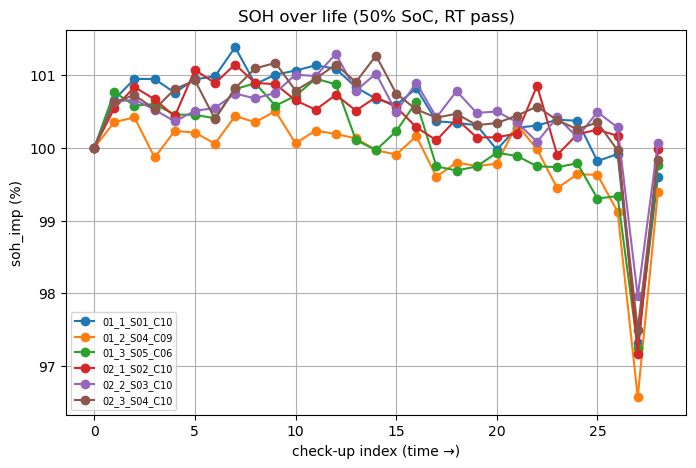

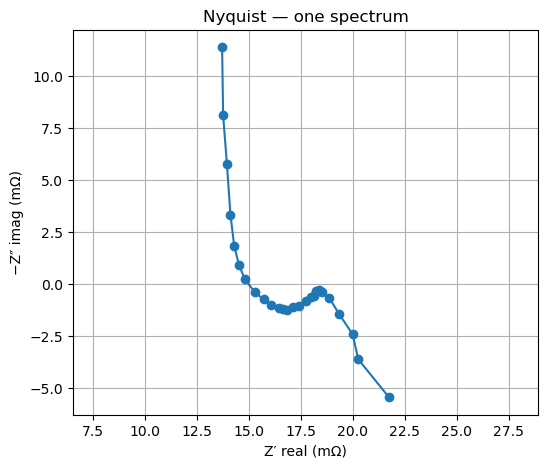

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/interim/eis_spectra.parquet")
print("cells:", df["cell_id"].nunique(), "| rows:", len(df))

# --- Check 1: SOH vs check-up index, for a few cells, at one fixed condition (50% SoC, RT pass) ---
cond = df[(df["soc_nom"] == 50) & (df["is_rt"] == 1)]
# one SOH value per (cell, check-up): every row in a spectrum shares the same soh_imp
soh_by_cu = cond.groupby(["cell_id", "cu_index"])["soh_imp"].first().reset_index()

plt.figure(figsize=(8, 5))
for cell in soh_by_cu["cell_id"].unique()[:6]:
    c = soh_by_cu[soh_by_cu["cell_id"] == cell]
    plt.plot(c["cu_index"], c["soh_imp"], marker="o", label=cell[-12:])
plt.xlabel("check-up index (time →)"); plt.ylabel("soh_imp (%)")
plt.title("SOH over life (50% SoC, RT pass)"); plt.legend(fontsize=7); plt.grid(True)
plt.show()

# --- Check 2: Nyquist plot of a single spectrum ---
one = df[df["cell_id"] == df["cell_id"].iloc[0]]
first_spec = one[(one["cu_index"] == one["cu_index"].min()) &
                 (one["soc_nom"] == 50) & (one["is_rt"] == 1)]
plt.figure(figsize=(6, 5))
plt.plot(first_spec["Z_real_mOhm"], -first_spec["Z_imag_mOhm"], marker="o")
plt.xlabel("Z′ real (mΩ)"); plt.ylabel("−Z″ imag (mΩ)")
plt.title("Nyquist — one spectrum"); plt.axis("equal"); plt.grid(True)
plt.show()


cell_id
cell_eisv2_P026_3_S03_C07   -65.938896
cell_eisv2_P026_2_S02_C07   -55.788410
cell_eisv2_P026_1_S01_C07   -54.749894
cell_eisv2_P054_1_S16_C06    21.635915
cell_eisv2_P055_3_S17_C04    25.632995
cell_eisv2_P054_2_S17_C06    27.460459
Name: soh_imp, dtype: float64


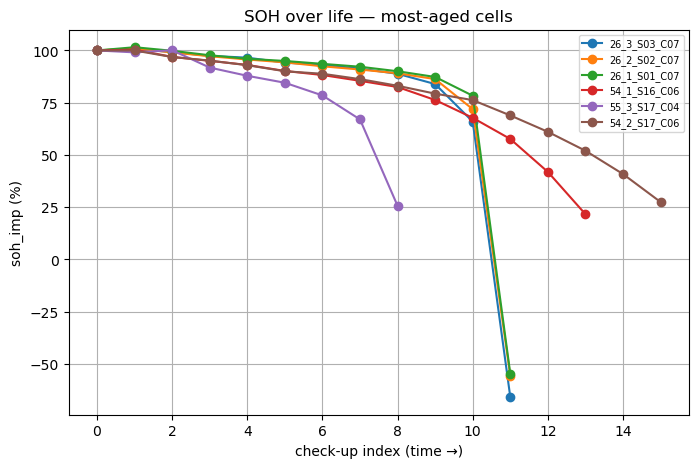

In [2]:
# find the cells that aged the most (lowest SOH they ever reached at 50% SoC, RT)
cond = df[(df["soc_nom"] == 50) & (df["is_rt"] == 1)]
soh_by_cu = cond.groupby(["cell_id", "cu_index"])["soh_imp"].first().reset_index()
worst = soh_by_cu.groupby("cell_id")["soh_imp"].min().sort_values().head(6)
print(worst)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
for cell in worst.index:
    c = soh_by_cu[soh_by_cu["cell_id"] == cell]
    plt.plot(c["cu_index"], c["soh_imp"], marker="o", label=cell[-12:])
plt.xlabel("check-up index (time →)"); plt.ylabel("soh_imp (%)")
plt.title("SOH over life — most-aged cells"); plt.legend(fontsize=7); plt.grid(True)
plt.show()


In [3]:
import pandas as pd

xl_path = "../data/raw/10.35097-1969/10.35097-1969/data/dataset/Cycling Experiment Cell Overview (2024-09-26 15-31).xlsx"
xl = pd.ExcelFile(xl_path)
print("SHEETS:", xl.sheet_names)

# peek at the first sheet
first = pd.read_excel(xl_path, sheet_name=xl.sheet_names[0])
print("shape:", first.shape)
print("columns:", list(first.columns))
first.head(10)


SHEETS: ['Parameters', 'Arrangement v01']
shape: (178, 24)
columns: ['Final Setup (06.10.2022) – status: 26.09.2024', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 1, 'Unnamed: 9', 2, 'Unnamed: 11', 3, 'Unnamed: 13', 'Unnamed: 14', 'cumulated', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Temperatures', 'Unnamed: 20', 'Unnamed: 21', 'Reference', 'Unnamed: 23']


,Final Setup (06.10.2022) – status: 26.09.2024,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,1,Unnamed: 9,...,Unnamed: 14,cumulated,Unnamed: 16,Unnamed: 17,Unnamed: 18,Temperatures,Unnamed: 20,Unnamed: 21,Reference,Unnamed: 23
0,Param.\nID,Age\nType,Temp.,SoC\nidle,SoC\nLimits,C-\nRates,Profile,Anz.\nZellen,Slave\n(1-19),Cell\n(0-11),...,NaN,Num\nCells,Per\nPool,Num\nSlaves,NaN,cal / cyc,NaN,NaN,NaN,NaN
1,1,Calendar,A,A,-,-,-,3,1,10,...,NaN,3,0.75,0.25,NaN,ID,°C,NaN,EOL_cap,NaN
2,2,Calendar,A,B,-,-,-,3,2,10,...,NaN,6,1.5,0.5,NaN,A,0,NaN,EOL_imp,NaN
3,3,Calendar,A,C,-,-,-,3,1,11,...,NaN,9,2.25,0.75,NaN,B,10,NaN,dQ+ err,NaN
4,4,Calendar,A,D,-,-,-,3,3,11,...,NaN,12,3,1,NaN,C,25,NaN,dSoc+ err,NaN
5,5,Calendar,B,A,-,-,-,3,7,9,...,NaN,15,3.75,1.25,NaN,D,40,NaN,dQ- err,NaN
6,6,Calendar,B,B,-,-,-,3,6,10,...,NaN,18,4.5,1.5,NaN,NaN,NaN,NaN,dSoc- err,NaN
7,7,Calendar,B,C,-,-,-,3,6,11,...,NaN,21,5.25,1.75,NaN,NaN,NaN,NaN,re-enabled (perm.),NaN
8,8,Calendar,B,D,-,-,-,3,7,11,...,NaN,24,6,2,NaN,SoC Calendar idle,NaN,NaN,re-enabled (for CU),NaN
9,9,Calendar,C,A,-,-,-,3,12,9,...,NaN,27,6.75,2.25,NaN,cal,NaN,NaN,Meas Err (over T),NaN


In [4]:
raw = pd.read_excel(xl_path, sheet_name=xl.sheet_names[0], header=1)

print("columns:", list(raw.columns)[:12])
print("total rows:", len(raw))

# the recipe rows are Param ID = 1..76 in the first column; keep just the columns we care about
print(raw.iloc[:, :8].head(20).to_string())


columns: ['Param.\nID', 'Age\nType', 'Temp.', 'SoC\nidle', 'SoC\nLimits', 'C-\nRates', 'Profile', 'Anz.\nZellen', 'Slave\n(1-19)', 'Cell\n(0-11)', 'Slave\n(1-19).1', 'Cell\n(0-11).1']
total rows: 177
   Param.\nID Age\nType Temp. SoC\nidle SoC\nLimits C-\nRates Profile Anz.\nZellen
0           1  Calendar     A         A           -         -       -            3
1           2  Calendar     A         B           -         -       -            3
2           3  Calendar     A         C           -         -       -            3
3           4  Calendar     A         D           -         -       -            3
4           5  Calendar     B         A           -         -       -            3
5           6  Calendar     B         B           -         -       -            3
6           7  Calendar     B         C           -         -       -            3
7           8  Calendar     B         D           -         -       -            3
8           9  Calendar     C         A           -  

In [5]:
# --- build clean recipe metadata table ---
recipe = pd.read_excel(xl_path, sheet_name=xl.sheet_names[0], header=1)
recipe.columns = [str(c).replace("\n", " ").strip() for c in recipe.columns]  # kill the newlines

recipe = recipe.rename(columns={
    "Param. ID": "param_id",
    "Age Type": "aging_type",
    "Temp.": "temp_cat",
    "SoC idle": "soc_idle_cat",
    "SoC Limits": "soc_limits_cat",
    "C- Rates": "c_rate_cat",
    "Profile": "profile",
})
keep = ["param_id", "aging_type", "temp_cat", "soc_idle_cat", "soc_limits_cat", "c_rate_cat", "profile"]
recipe = recipe[keep].copy()

# keep only real recipe rows (numeric param_id 1..76)
recipe = recipe[pd.to_numeric(recipe["param_id"], errors="coerce").notna()]
recipe["param_id"] = recipe["param_id"].astype(int)
recipe = recipe[recipe["param_id"].between(1, 76)].reset_index(drop=True)

# decode temperature category -> real setpoint in Celsius
recipe["temp_setpoint_degC"] = recipe["temp_cat"].map({"A": 0, "B": 10, "C": 25, "D": 40})

print("recipes:", len(recipe))
print(recipe["aging_type"].value_counts())

# --- join onto the spectra table ---
df = pd.read_parquet("../data/interim/eis_spectra.parquet")
df["param_id"] = df["pack"].str[1:].astype(int)     # 'P001' -> 1
merged = df.merge(recipe, on="param_id", how="left")

# verify every cell got its recipe
missing = merged["aging_type"].isna().sum()
print("rows with no recipe match:", missing)
print("cells per aging type:")
print(merged.groupby("aging_type")["cell_id"].nunique())


recipes: 87
aging_type
Cyclic      48
Calendar    16
Profile     12
2            1
3            1
4            1
5            1
6            1
7            1
8            1
9            1
10           1
11           1
12           1
Name: count, dtype: int64
rows with no recipe match: 0
cells per aging type:
aging_type
2             3
3             3
4             3
5             3
6             3
7             3
8             3
9             3
10            3
11            3
12            3
Calendar     48
Cyclic      144
Profile      36
Name: cell_id, dtype: int64


In [6]:
# --- rebuild recipe table, keeping ONLY real recipe rows ---
recipe = pd.read_excel(xl_path, sheet_name=xl.sheet_names[0], header=1)
recipe.columns = [str(c).replace("\n", " ").strip() for c in recipe.columns]
recipe = recipe.rename(columns={
    "Param. ID": "param_id", "Age Type": "aging_type", "Temp.": "temp_cat",
    "SoC idle": "soc_idle_cat", "SoC Limits": "soc_limits_cat",
    "C- Rates": "c_rate_cat", "Profile": "profile",
})
recipe = recipe[["param_id", "aging_type", "temp_cat", "soc_idle_cat",
                 "soc_limits_cat", "c_rate_cat", "profile"]].copy()

# the clean filter: real recipes have aging_type in these three values
recipe = recipe[recipe["aging_type"].isin(["Calendar", "Cyclic", "Profile"])].copy()
recipe["param_id"] = recipe["param_id"].astype(int)
recipe["temp_setpoint_degC"] = recipe["temp_cat"].map({"A": 0, "B": 10, "C": 25, "D": 40})

print("recipes:", len(recipe))
print("unique param_ids:", recipe["param_id"].nunique())   # must equal len(recipe)
print(recipe["aging_type"].value_counts())

# GUARD: recipe keys must be unique before joining
assert recipe["param_id"].is_unique, "recipe param_id not unique -> join would duplicate!"

# --- join, then verify NO rows were added ---
df = pd.read_parquet("../data/interim/eis_spectra.parquet")
df["param_id"] = df["pack"].str[1:].astype(int)
merged = df.merge(recipe, on="param_id", how="left")

assert len(merged) == len(df), f"join changed row count! {len(df)} -> {len(merged)}"
print("row count preserved:", len(merged) == len(df))
print("rows with no recipe match:", merged["aging_type"].isna().sum())
print("cells per aging type:")
print(merged.groupby("aging_type")["cell_id"].nunique())


recipes: 76
unique param_ids: 76
aging_type
Cyclic      48
Calendar    16
Profile     12
Name: count, dtype: int64
row count preserved: True
rows with no recipe match: 0
cells per aging type:
aging_type
Calendar     48
Cyclic      144
Profile      36
Name: cell_id, dtype: int64


In [1]:
import sys
sys.path.insert(0, "..")
from src.prep.metadata import build_enriched_table

RECIPE_XLSX = "../data/raw/10.35097-1969/10.35097-1969/data/dataset/Cycling Experiment Cell Overview (2024-09-26 15-31).xlsx"

enriched = build_enriched_table(
    spectra_parquet="../data/interim/eis_spectra.parquet",
    recipe_xlsx=RECIPE_XLSX,
    save_path="../data/interim/eis_enriched.parquet",
)

print("shape:", enriched.shape)
print("columns:", list(enriched.columns))
print("cells:", enriched["cell_id"].nunique())
enriched.groupby("aging_type")["cell_id"].nunique()


shape: (1102304, 24)
columns: ['cell_id', 'pack', 'replicate', 'board', 'channel', 'cu_index', 'soc_nom', 'is_rt', 'freq_Hz', 'Z_real_mOhm', 'Z_imag_mOhm', 'temp_degC', 'soh_imp', 'z_ref_init_mOhm', 'z_ref_now_mOhm', 'valid', 'param_id', 'aging_type', 'temp_cat', 'soc_idle_cat', 'soc_limits_cat', 'c_rate_cat', 'profile', 'temp_setpoint_degC']
cells: 228


aging_type
Calendar     48
Cyclic      144
Profile      36
Name: cell_id, dtype: int64

cyc_condition vs soh_cap-present crosstab:
soh_cap        False  True 
cyc_condition              
0                372      0
2                  0     58

capacity measurements in this cell: 58
soh_cap range: 84.27 to 98.75


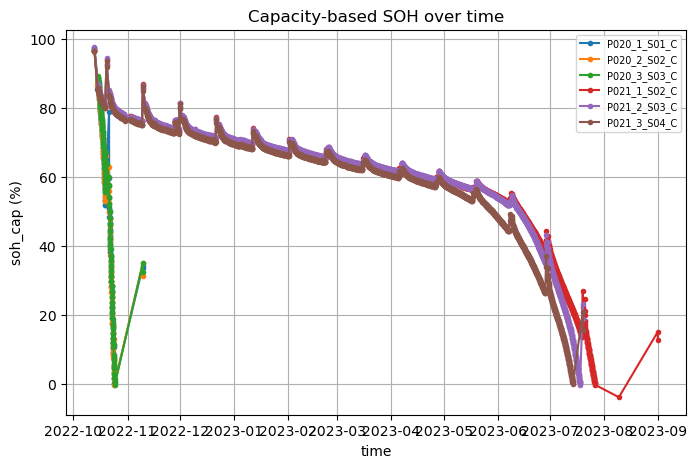

In [1]:
import pandas as pd, glob, os, matplotlib.pyplot as plt

EOC_DIR = "../data/raw/10.35097-1969/10.35097-1969/data/dataset/cell_eocv2"

# one cell first
f = os.path.join(EOC_DIR, "cell_eocv2_P001_1_S01_C10.csv")
d = pd.read_csv(f, sep=";")

# confirm: soh_cap is present exactly when cyc_condition == 2
print("cyc_condition vs soh_cap-present crosstab:")
print(pd.crosstab(d["cyc_condition"], d["soh_cap"].notna()))

# the capacity measurements only
cap = d[d["soh_cap"].notna()].copy()
print("\ncapacity measurements in this cell:", len(cap))
print("soh_cap range:", round(cap["soh_cap"].min(), 2), "to", round(cap["soh_cap"].max(), 2))

# plot capacity-SOH over time for a few most-aged cells
plt.figure(figsize=(8, 5))
for f in sorted(glob.glob(os.path.join(EOC_DIR, "cell_eocv2_P0[2-5]*.csv")))[:6]:
    dd = pd.read_csv(f, sep=";")
    c = dd[dd["soh_cap"].notna()]
    if len(c):
        plt.plot(pd.to_datetime(c["timestamp_s"], unit="s"), c["soh_cap"],
                 marker=".", label=os.path.basename(f)[11:23])
plt.xlabel("time"); plt.ylabel("soh_cap (%)"); plt.title("Capacity-based SOH over time")
plt.legend(fontsize=7); plt.grid(True); plt.show()


In [3]:
import sys
sys.path.insert(0, "..")
from src.prep.load_eis import assign_cu_index

f = os.path.join(EOC_DIR, "cell_eocv2_P001_1_S01_C10.csv")
d = pd.read_csv(f, sep=";")
cap = d[d["soh_cap"].notna()].copy()

# reconstruct the check-up index on the capacity-measurement timestamps
ts = pd.Series(sorted(cap["timestamp_s"].unique()))
ts_to_cu = pd.Series(assign_cu_index(ts).values, index=ts.values)
cap["cu_index"] = cap["timestamp_s"].map(ts_to_cu)

print("measurements per check-up (distribution):")
print(cap.groupby("cu_index").size().value_counts())

# inspect one check-up's rows to see what distinguishes the duplicates
cols = ["timestamp_s", "cyc_charged", "num_cycles_checkup", "soh_cap",
        "cap_aged_est_Ah", "delta_q_chg_Ah", "delta_q_dischg_Ah"]
print("\none check-up's capacity rows:")
print(cap[cap["cu_index"] == 5][cols].to_string(index=False))


measurements per check-up (distribution):
2    29
Name: count, dtype: int64

one check-up's capacity rows:
 timestamp_s  cyc_charged  num_cycles_checkup   soh_cap  cap_aged_est_Ah  delta_q_chg_Ah  delta_q_dischg_Ah
1673462545.0            1                   5 95.052099         2.925781        2.901843           0.000000
1673473364.0            0                   5 93.939209         2.909088        0.000000          -2.883106


In [4]:
import glob, os, pandas as pd

EOC_DIR = "../data/raw/10.35097-1969/10.35097-1969/data/dataset/cell_eocv2"

def load_capacity_labels(eoc_dir):
    rows = []
    for f in sorted(glob.glob(os.path.join(eoc_dir, "cell_eocv2_*.csv"))):
        d = pd.read_csv(f, sep=";")
        if len(d) == 0:                      # skip empty P000 placeholders
            continue
        # discharge-capacity check-up measurements only
        cap = d[(d["soh_cap"].notna()) & (d["cyc_charged"] == 0)].copy()
        if len(cap) == 0:
            continue
        cap["cell_key"] = os.path.basename(f).replace("cell_eocv2_", "").replace(".csv", "")
        rows.append(cap[["cell_key", "timestamp_s", "soh_cap", "cap_aged_est_Ah"]])
    return pd.concat(rows, ignore_index=True)

caps = load_capacity_labels(EOC_DIR)
print("cells with capacity data:", caps["cell_key"].nunique())
print("total discharge-capacity measurements:", len(caps))
print("soh_cap range:", round(caps["soh_cap"].min(), 1), "to", round(caps["soh_cap"].max(), 1))
print("measurements per cell:")
print(caps.groupby("cell_key").size().describe())


cells with capacity data: 228
total discharge-capacity measurements: 265355
soh_cap range: -35.1 to 98.0
measurements per cell:
count     228.000000
mean     1163.837719
std      1619.749811
min         5.000000
25%        29.000000
50%       525.500000
75%      1579.000000
max      8779.000000
dtype: float64


In [5]:
import glob, os, pandas as pd

EOC_DIR = "../data/raw/10.35097-1969/10.35097-1969/data/dataset/cell_eocv2"

def load_capacity_labels(eoc_dir):
    rows = []
    for f in sorted(glob.glob(os.path.join(eoc_dir, "cell_eocv2_*.csv"))):
        d = pd.read_csv(f, sep=";")
        if len(d) == 0:
            continue
        # CHECK-UP discharge capacity only:
        #   cyc_condition == 2  -> standardized check-up test (at RT), not operational cycling
        #   cyc_charged   == 0  -> discharge (usable capacity, the standard SOH)
        cap = d[(d["cyc_condition"] == 2) & (d["cyc_charged"] == 0)].copy()
        if len(cap) == 0:
            continue
        cap["cell_key"] = os.path.basename(f).replace("cell_eocv2_", "").replace(".csv", "")
        rows.append(cap[["cell_key", "timestamp_s", "soh_cap", "cap_aged_est_Ah", "t_start_degC"]])
    return pd.concat(rows, ignore_index=True)

caps = load_capacity_labels(EOC_DIR)
print("cells with capacity data:", caps["cell_key"].nunique())
print("total check-up discharge measurements:", len(caps))
print("measurements per cell:")
print(caps.groupby("cell_key").size().describe())
print("check-up capacity temperature (should cluster ~25°C):")
print(caps["t_start_degC"].round(0).describe())
print("soh_cap range:", round(caps["soh_cap"].min(), 1), "to", round(caps["soh_cap"].max(), 1))


cells with capacity data: 228
total check-up discharge measurements: 3999
measurements per cell:
count    228.000000
mean      17.539474
std       10.450775
min        2.000000
25%        7.000000
50%       16.000000
75%       29.000000
max       29.000000
dtype: float64
check-up capacity temperature (should cluster ~25°C):
count    3999.000000
mean       25.128032
std         0.915440
min         1.000000
25%        25.000000
50%        25.000000
75%        25.000000
max        28.000000
Name: t_start_degC, dtype: float64
soh_cap range: -35.1 to 98.0


In [6]:
enriched = pd.read_parquet("../data/interim/eis_enriched.parquet")
enriched["cell_key"] = enriched["cell_id"].str.replace("cell_eisv2_", "", regex=False)

caps2 = caps.copy()
caps2["cap_timestamp_s"] = caps2["timestamp_s"]   # keep a copy to measure match distance

left = enriched.sort_values("timestamp_s")
right = caps2[["cell_key", "timestamp_s", "cap_timestamp_s",
               "soh_cap", "cap_aged_est_Ah"]].sort_values("timestamp_s")

labeled = pd.merge_asof(
    left, right,
    on="timestamp_s", by="cell_key",
    direction="nearest",
    tolerance=3 * 24 * 3600,        # 3 days: same check-up, never the neighbour
)

print("total spectra rows:", len(labeled))
print("rows with a soh_cap label:", labeled["soh_cap"].notna().sum())
print("match rate:", round(labeled["soh_cap"].notna().mean() * 100, 1), "%")

# how far (in time) is each spectrum from its matched capacity test?
gap_days = (labeled["timestamp_s"] - labeled["cap_timestamp_s"]).abs() / 86400
print("\nmatch time-gap in days (matched rows):")
print(gap_days.describe())


KeyError: 'timestamp_s'

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
from src.prep.load_eis import load_all_cells
from src.prep.metadata import build_enriched_table
from src.prep.capacity import load_capacity_labels, attach_capacity_labels

DS = "../data/raw/10.35097-1969/10.35097-1969/data/dataset"

# 1. rebuild spectra table (now includes timestamp_s)
load_all_cells(f"{DS}/cell_eisv2", save_path="../data/interim/eis_spectra.parquet")

# 2. rebuild enriched table (spectra + recipe metadata)
enriched = build_enriched_table(
    "../data/interim/eis_spectra.parquet",
    f"{DS}/Cycling Experiment Cell Overview (2024-09-26 15-31).xlsx",
    save_path="../data/interim/eis_enriched.parquet",
)

# 3. capacity labels + 4. nearest-time alignment
caps = load_capacity_labels(f"{DS}/cell_eocv2")
labeled = attach_capacity_labels(enriched, caps, tolerance_days=3.0)

print("total spectra rows:", len(labeled))
print("match rate:", round(labeled["soh_cap"].notna().mean() * 100, 1), "%")
gap_days = (labeled["timestamp_s"] - labeled["cap_timestamp_s"]).abs() / 86400
print("\nmatch time-gap in days:")
print(gap_days.describe())


total spectra rows: 1102304
match rate: 100.0 %

match time-gap in days:
count    1.102304e+06
mean     5.407572e-01
std      4.434469e-01
min      1.464120e-02
25%      1.651042e-01
50%      4.804167e-01
75%      8.038368e-01
max      2.224977e+00
dtype: float64


In [2]:
labeled.to_parquet("../data/interim/eis_labeled.parquet", index=False)
print("shape:", labeled.shape)
print("columns:", list(labeled.columns))
print("cells:", labeled["cell_id"].nunique())

shape: (1102304, 29)
columns: ['cell_id', 'pack', 'replicate', 'board', 'channel', 'cu_index', 'timestamp_s', 'soc_nom', 'is_rt', 'freq_Hz', 'Z_real_mOhm', 'Z_imag_mOhm', 'temp_degC', 'soh_imp', 'z_ref_init_mOhm', 'z_ref_now_mOhm', 'valid', 'param_id', 'aging_type', 'temp_cat', 'soc_idle_cat', 'soc_limits_cat', 'c_rate_cat', 'profile', 'temp_setpoint_degC', 'cell_key', 'cap_timestamp_s', 'soh_cap', 'cap_aged_est_Ah']
cells: 228


In [ ]:
import time

t = time.time()
labeled = labeled.sort_values(
    ["param_id", "replicate", "cu_index", "is_rt", "soc_nom", "freq_Hz"],
    ascending=[True,        True,        True,       False,   True,      False],
).reset_index(drop=True)
print("sort took:", round(time.time() - t, 1), "s")

t = time.time()
labeled.to_parquet("../data/interim/eis_labeled.parquet", index=False)
print("write took:", round(time.time() - t, 1), "s")

In [5]:
import pandas as pd
pd.set_option("display.max_columns", None)

labeled = pd.read_parquet("../data/interim/eis_labeled.parquet")

# view ONE cell, nicely ordered — instant
view = labeled[labeled["cell_id"] == "cell_eisv2_P001_1_S01_C10"].sort_values(
    ["cu_index", "is_rt", "soc_nom", "freq_Hz"],
    ascending=[True, False, True, False],
)
view.head(60)


,cell_id,pack,replicate,board,channel,cu_index,timestamp_s,soc_nom,is_rt,freq_Hz,Z_real_mOhm,Z_imag_mOhm,temp_degC,soh_imp,z_ref_init_mOhm,z_ref_now_mOhm,valid,param_id,aging_type,temp_cat,soc_idle_cat,soc_limits_cat,c_rate_cat,profile,temp_setpoint_degC,cell_key,cap_timestamp_s,soh_cap,cap_aged_est_Ah
2216,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,10000.0000,13.758,-11.192,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2217,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,6756.7568,13.839,-7.921,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2224,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,5000.0000,13.997,-5.765,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2225,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,3125.0000,14.177,-3.342,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2238,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,2083.3333,14.380,-1.773,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2235,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,1470.5883,14.609,-0.864,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2234,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,1000.0000,14.926,-0.171,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2236,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,675.6757,15.418,0.580,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2237,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,500.0000,15.861,1.059,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
2215,cell_eisv2_P001_1_S01_C10,P001,1,S01,C10,0,1.665659e+09,10,1,312.5000,16.278,1.378,24.95,100.0,25.008,25.008,1,1,Calendar,A,A,-,-,-,0,P001_1_S01_C10,1.665626e+09,97.849625,2.967744
